In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
batch_size = 128

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               transform=transform,
                               download=True)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.43MB/s]


The MNIST dataset (handwritten digits 0–9) is loaded and converted into tensor format so PyTorch can process it. The DataLoader divides the dataset into batches of 128 images and shuffles them to improve training.

In [9]:
class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 20)
        self.fc_logvar = nn.Linear(400, 20)

        # Decoder
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    # Encoder
    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    # Reparameterization Trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    # Decoder
    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    # Forward Pass
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

This block defines the encoder network of the VAE. The 28×28 MNIST image is flattened into 784 features, passed through a hidden layer, and converted into two outputs:

μ (mean) of the latent distribution

log(σ²) (log variance) which represents uncertainty in the latent space.

In [10]:
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

The reparameterization trick allows the model to sample a latent vector while still allowing gradients to flow during training. Instead of sampling directly from a distribution, random noise is combined with the mean and standard deviation to produce the latent vector z.

In [11]:
    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

Decoder and Forward Pass

The decoder reconstructs the image from the latent vector z. The forward pass performs the full VAE process: encoding the input, sampling the latent vector, and reconstructing the image.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

The VAE model is initialized and moved to GPU for faster computation. The Adam optimizer is used to update the model weights during training.

In [13]:
def loss_function(recon_x, x, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_divergence, reconstruction_loss, kl_divergence

The VAE loss consists of two components:

Reconstruction Loss
Measures how well the decoder recreates the original image.

KL Divergence Loss
Ensures the latent variables follow a normal distribution so the model can generate meaningful samples.

The total VAE loss is the sum of these two losses.

In [14]:
epochs = 10

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for data, _ in train_loader:

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss, recon_loss, kl_loss = loss_function(
            recon_batch, data, mu, logvar
        )

        loss.backward()

        train_loss += loss.item()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Reconstruction Loss: {recon_loss.item():.2f}")
    print(f"KL Divergence Loss: {kl_loss.item():.2f}")

Epoch 1/10
Reconstruction Loss: 10466.92
KL Divergence Loss: 2017.57
Epoch 2/10
Reconstruction Loss: 9034.19
KL Divergence Loss: 2258.04
Epoch 3/10
Reconstruction Loss: 8404.17
KL Divergence Loss: 2207.44
Epoch 4/10
Reconstruction Loss: 8091.40
KL Divergence Loss: 2379.08
Epoch 5/10
Reconstruction Loss: 8174.66
KL Divergence Loss: 2336.94
Epoch 6/10
Reconstruction Loss: 8173.85
KL Divergence Loss: 2346.15
Epoch 7/10
Reconstruction Loss: 8119.12
KL Divergence Loss: 2451.40
Epoch 8/10
Reconstruction Loss: 7875.63
KL Divergence Loss: 2375.83
Epoch 9/10
Reconstruction Loss: 7707.50
KL Divergence Loss: 2404.70
Epoch 10/10
Reconstruction Loss: 7891.01
KL Divergence Loss: 2441.39


During training, the reconstruction loss decreased significantly, indicating that the decoder learned to reconstruct the input images effectively. The KL divergence loss remained relatively stable, ensuring that the latent space followed a Gaussian distribution. The results demonstrate that the VAE successfully balances reconstruction accuracy with latent space regularization, enabling meaningful representation learning of handwritten digits.

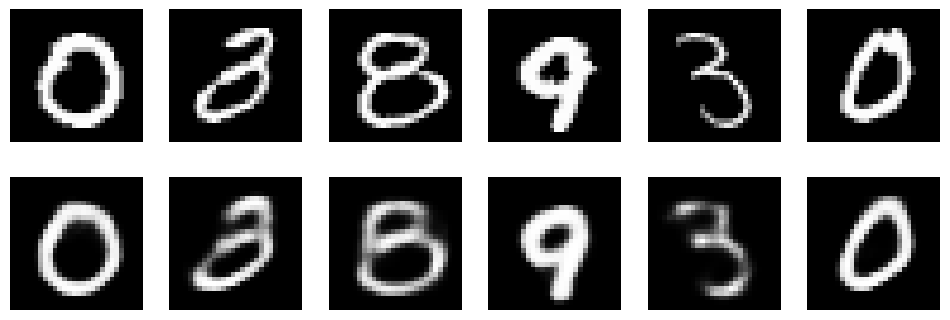

In [15]:
model.eval()

with torch.no_grad():

    data, _ = next(iter(train_loader))
    data = data.view(-1, 784).to(device)

    recon, _, _ = model(data)

    fig, ax = plt.subplots(2,6, figsize=(12,4))

    for i in range(6):
        ax[0,i].imshow(data[i].cpu().view(28,28), cmap='gray')
        ax[0,i].axis('off')

        ax[1,i].imshow(recon[i].cpu().view(28,28), cmap='gray')
        ax[1,i].axis('off')

plt.show()

The reconstructed images generated by the Variational Autoencoder closely resemble the original MNIST digits, indicating that the encoder successfully learned meaningful latent representations and the decoder was able to reconstruct the images from the latent space.

The reconstructed digits appear slightly blurred compared to the originals, which is expected in VAE models due to probabilistic reconstruction. Overall, the results demonstrate that the VAE effectively learns compressed representations while maintaining the ability to reconstruct handwritten digits.